# Stitchkit 0.2 — 実行結果・計測・設計検証

このNotebookは**nanobindで結合したC++実装を直接呼び出します**。外部実行ファイルをPythonから呼ぶ代替実装ではありません。

評価対象はREW、NISwGSP、GES-GSPに基づく独立実装です。著者実装の完全再現、論文掲載値の再現、GPU高速化の実測を主張しません。

## 計測条件
全処理（入力配列のC++への複製、特徴点対応、変形推定、描画）と、位置合わせ結果を再利用する処理を別々に測ります。
画像読込・JSONの解析・保存・図表作成は計測区間外です。各条件で予備実行1回、本計測5回を行い、実行順だけを固定乱数で交互に入れ替えます。
中央値と四分位範囲を使用し、5回から精密な上位パーセンタイルや有意差を主張しません。

位置合わせ済み処理でも構造検出と変形推定・描画は毎回実行します。再利用対象は入力画像と特徴点対応です。


In [1]:
from pathlib import Path
import os, sys, json, platform, hashlib, subprocess, importlib.metadata
from datetime import datetime, timezone
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
import stitchkit as sk
from stitchkit.benchmark import benchmark_images, reference_metrics

# Notebookをプロジェクト直下・notebooks直下のいずれから開いても動作します。
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "tests/assets/manifest.json").exists()), None)
if ROOT is None:
    raise RuntimeError("画像資産を含むプロジェクト内で実行してください")
ASSETS = ROOT / "tests/assets"
OUT = ROOT / "results/notebook"
OUT.mkdir(parents=True, exist_ok=True)
OPTIONS = sk.Options(device="cpu", seed=42)
REPEATS, WARMUPS, ORDER_SEED = 5, 1, 314159
assert sk.__version__ == "0.2.0"
print("C++拡張:", sk._native.__file__)
print("機能:", sk.capabilities())

C++拡張: [EPHEMERAL_ROOT]/stitchkit_review/.venv/lib/python3.13/site-packages/stitchkit/_native.cpython-313-x86_64-linux-gnu.so
機能: {'version': '0.2.0', 'cxx_compiler': 'GNU 14.2.0', 'configuration': 'Release', 'nanobind': '2.15.0', 'cuda_compiled': False, 'cuda_available': False, 'lineae_compiled': False, 'gpu_scope': 'sampling and compositing only'}


In [2]:
cpu_name = platform.processor() or "unknown"
if Path("/proc/cpuinfo").exists():
    cpu_name = next((line.split(":", 1)[1].strip() for line in Path("/proc/cpuinfo").read_text().splitlines() if line.startswith("model name")), cpu_name)
packages = {name: importlib.metadata.version(name) for name in ["numpy", "pandas", "matplotlib", "nanobind", "scikit-build-core", "nbclient", "ipykernel"]}
environment = {
    "timestamp_utc": datetime.now(timezone.utc).isoformat(), "python": sys.version,
    "platform": platform.platform(), "cpu": cpu_name, "logical_cpus": os.cpu_count(),
    "cpu_affinity_count": len(os.sched_getaffinity(0)) if hasattr(os, "sched_getaffinity") else None,
    "uv": subprocess.run(["uv", "--version"], text=True, capture_output=True, check=True).stdout.strip(),
    "packages": packages, "capabilities": sk.capabilities(), "options": OPTIONS.as_dict(),
    "native_extension_sha256": hashlib.sha256(Path(sk._native.__file__).read_bytes()).hexdigest(),
    "repeats": REPEATS, "warmups": WARMUPS, "order_seed": ORDER_SEED,
    "thread_environment": {k: os.environ.get(k) for k in ["OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS"]},
    "notes": ["共有された実行環境です。CPU固定・周波数固定は行っていません。", "全処理と再利用処理は測定範囲が異なります。"],
}
# 実験に使用した計算コード・構成を識別します。実行で変わるNotebook自身は除きます。
source_paths = [ROOT / name for name in ["CMakeLists.txt", "pyproject.toml", "vcpkg.json"]]
for folder in ["src", "include", "bindings", "python", "tools"]:
    source_paths.extend(p for p in (ROOT / folder).rglob("*")
                        if p.is_file() and p.suffix in {".cpp", ".h", ".hpp", ".cu", ".py", ".pyi"})
source_manifest = {p.relative_to(ROOT).as_posix(): hashlib.sha256(p.read_bytes()).hexdigest()
                   for p in sorted(set(source_paths))}
(OUT / "source_manifest.json").write_text(json.dumps(source_manifest, indent=2) + "\n")
environment["source_manifest_sha256"] = hashlib.sha256((OUT / "source_manifest.json").read_bytes()).hexdigest()
(OUT / "environment.json").write_text(json.dumps(environment, indent=2, ensure_ascii=False) + "\n")
display(pd.DataFrame([{"項目":"CPU", "値":cpu_name}, {"項目":"Python", "値":platform.python_version()}, {"項目":"uv", "値":environment["uv"]}] + [{"項目":k,"値":v} for k,v in packages.items()]))

,項目,値
0,CPU,AMD EPYC 9V74 80-Core Processor
1,Python,3.13.5
2,uv,uv 0.10.0
3,numpy,2.3.5
4,pandas,2.2.3
5,matplotlib,3.10.8
6,nanobind,2.15.0
7,scikit-build-core,1.1.0
8,nbclient,0.10.4
9,ipykernel,7.2.0


## 入力画像と出所
合成例2組には、既知の平行移動から作った正解画像があります。局所視差例と実画像3組は、ここでは正解画像との品質点数を算出しません。
実画像の出所・利用条件は `tests/assets/PROVENANCE.md` を参照してください。実画像は長辺640画素以下、合成画像は原寸400×280画素です。


In [3]:
cases = {
    "translation": ["synthetic/view0.png", "synthetic/view1.png"],
    "chain": ["synthetic/view0.png", "synthetic/view1.png", "synthetic/view2.png"],
    "parallax": ["synthetic/view0.png", "synthetic/parallax1.png"],
    "library": ["real/lib1.jpg", "real/lib2.jpg"],
    "town_hall": ["real/town_hall1.jpg", "real/town_hall2.jpg"],
    "ship": ["real/ship1.jpg", "real/ship2.jpg"],
}
inputs, asset_records = {}, []
for case, paths in cases.items():
    inputs[case] = [sk.load(ASSETS / p, max_side=640 if p.startswith("real/") else 0) for p in paths]
    for path, image in zip(paths, inputs[case]):
        asset_records.append({"case":case, "path":path, "width":image.shape[1], "height":image.shape[0],
                              "sha256":hashlib.sha256((ASSETS / path).read_bytes()).hexdigest()})
asset_table = pd.DataFrame(asset_records)
asset_table.to_csv(OUT / "input_assets.csv", index=False)
display(asset_table.drop(columns="sha256"))


,case,path,width,height
0,translation,synthetic/view0.png,400,280
1,translation,synthetic/view1.png,400,280
2,chain,synthetic/view0.png,400,280
3,chain,synthetic/view1.png,400,280
4,chain,synthetic/view2.png,400,280
5,parallax,synthetic/view0.png,400,280
6,parallax,synthetic/parallax1.png,400,280
7,library,real/lib1.jpg,640,397
8,library,real/lib2.jpg,640,397
9,town_hall,real/town_hall1.jpg,640,360


## 反復計測
全ての結果は同じPython APIから得ています。試行のたびに、同一手法の出力画素とマスクが過去の試行と一致することも確認します。
この一致確認は計測区間の外で行います。失敗した試行を黙って除外する処理はありません。


In [4]:
runs = {}
for case, images in inputs.items():
    runs[case] = benchmark_images(images, case=case, options=OPTIONS, repeats=REPEATS,
                                  warmups=WARMUPS, seed=ORDER_SEED)
    print(case, "完了:", len(runs[case].records), "測定")
raw = pd.DataFrame([record for run in runs.values() for record in run.records])
raw.to_csv(OUT / "timings_raw.csv", index=False)
preparation = pd.DataFrame([run.preparation for run in runs.values()])
preparation.to_csv(OUT / "preparation.csv", index=False)
assert len(raw) == len(cases) * 3 * 2 * REPEATS
assert raw.actual_device.eq("cpu").all()
assert raw[raw.scope.eq("prepared")].registration_ms.eq(0).all()
assert raw[raw.scope.eq("prepared")].feature_extractions.eq(0).all()
print("総測定数:", len(raw))


translation 完了: 30 測定


chain 完了: 30 測定


parallax 完了: 30 測定


library 完了: 30 測定


town_hall 完了: 30 測定


ship 完了: 30 測定
総測定数: 180


In [5]:
summary = raw.groupby(["case", "method", "scope"], sort=False).wall_ms.agg(
    count="count", median_ms="median", mean_ms="mean", minimum_ms="min", maximum_ms="max",
    p25_ms=lambda s: s.quantile(.25), p75_ms=lambda s: s.quantile(.75)).reset_index()
summary["iqr_ms"] = summary.p75_ms - summary.p25_ms
summary.to_csv(OUT / "timings_summary.csv", index=False)
display(summary.round(3))


,case,method,scope,count,median_ms,mean_ms,minimum_ms,maximum_ms,p25_ms,p75_ms,iqr_ms
0,translation,gesgsp,end_to_end,5,671.565,680.463,664.195,722.732,670.265,673.558,3.292
1,translation,niswgsp,end_to_end,5,357.928,358.778,351.441,368.453,356.824,359.244,2.420
2,translation,gesgsp,prepared,5,535.660,535.907,530.251,542.862,534.426,536.336,1.910
3,translation,niswgsp,prepared,5,224.260,225.645,222.807,229.707,222.912,228.541,5.629
4,translation,rew,prepared,5,19.581,19.276,18.604,19.683,18.861,19.650,0.789
5,translation,rew,end_to_end,5,148.673,149.166,145.954,152.857,146.759,151.589,4.829
6,chain,gesgsp,end_to_end,5,2121.234,2149.651,2087.083,2282.517,2119.554,2137.866,18.312
7,chain,niswgsp,end_to_end,5,805.964,807.481,776.613,839.784,792.327,822.720,30.393
8,chain,gesgsp,prepared,5,1942.384,1934.013,1858.084,1992.746,1933.717,1943.136,9.420
9,chain,niswgsp,prepared,5,604.603,608.302,581.404,637.962,593.039,624.503,31.464


### 全処理と位置合わせ済み処理の比較
下表の倍率は、同じ手法の全処理中央値を、準備費用を除いた処理中央値で割った値です。
「アルゴリズム自体がその倍率で高速化した」という意味ではありません。初回の準備時間は別表に示します。


scope,case,method,end_to_end,prepared,ratio_excluding_prepare
0,chain,gesgsp,2121.234,1942.384,1.092
1,chain,niswgsp,805.964,604.603,1.333
2,chain,rew,255.088,44.948,5.675
3,library,gesgsp,4143.085,3744.721,1.106
4,library,niswgsp,2084.200,1802.290,1.156
5,library,rew,366.547,49.455,7.412
6,parallax,gesgsp,711.042,570.117,1.247
7,parallax,niswgsp,361.889,219.297,1.650
8,parallax,rew,158.349,17.770,8.911
9,ship,gesgsp,2789.385,2546.749,1.095


,case,prepare_wall_ms,registration_ms,feature_extractions,images,input_bytes
0,translation,151.007,150.648,2,2,672000
1,chain,214.611,214.447,3,3,1008000
2,parallax,141.398,141.228,2,2,672000
3,library,327.960,327.749,2,2,1524480
4,town_hall,247.827,247.609,2,2,1382400
5,ship,208.033,207.835,2,2,1451520


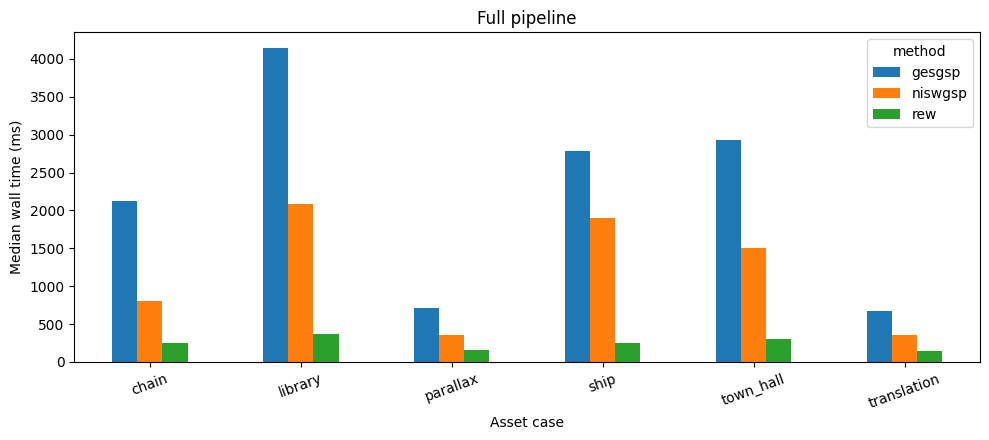

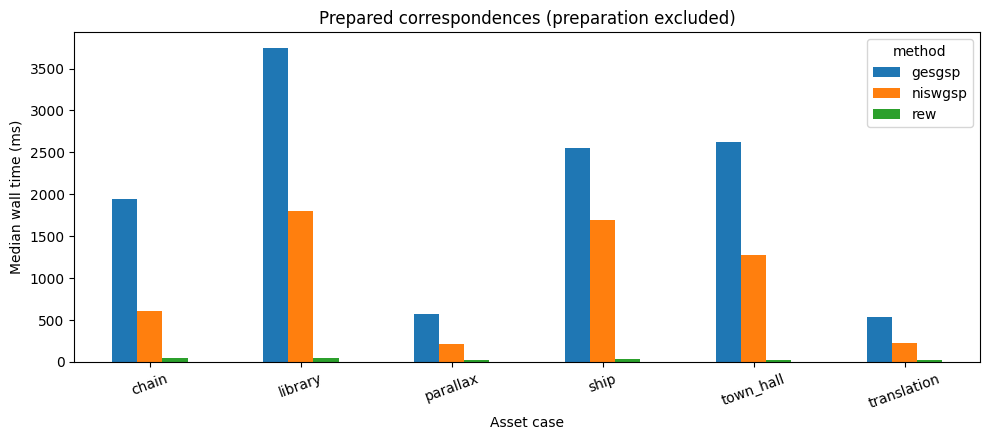

In [6]:
comparison = summary.pivot(index=["case", "method"], columns="scope", values="median_ms").reset_index()
comparison["ratio_excluding_prepare"] = comparison.end_to_end / comparison.prepared
comparison.to_csv(OUT / "scope_comparison.csv", index=False)
display(comparison.round(3))
display(preparation.round(3))

for scope in ["end_to_end", "prepared"]:
    pivot = summary[summary.scope.eq(scope)].pivot(index="case", columns="method", values="median_ms")
    fig, ax = plt.subplots(figsize=(10, 4.5))
    pivot.plot.bar(ax=ax)
    ax.set_ylabel("Median wall time (ms)")
    ax.set_xlabel("Asset case")
    ax.set_title("Full pipeline" if scope == "end_to_end" else "Prepared correspondences (preparation excluded)")
    ax.tick_params(axis="x", rotation=20)
    fig.tight_layout()
    fig.savefig(OUT / f"timing_{scope}.png", dpi=150)
    plt.show()


### 処理段階別の内訳
C++内部の計測は、特徴点対応、構造検出、変形と逆写像の構築、描画に分けています。
Python側の実測時間との差には、引数の検査・配列の複製・C++オブジェクトの構築・戻り値の生成などが含まれます。
差分を「nanobind呼出しだけの費用」と解釈しないでください。


In [7]:
stage_columns = ["registration_ms", "structure_ms", "geometry_ms", "render_ms", "total_ms", "wall_ms"]
stages = raw.groupby(["case", "method", "scope"])[stage_columns].median().reset_index()
stages.to_csv(OUT / "stage_medians.csv", index=False)
display(stages[stages.case.eq("library")].round(3))


,case,method,scope,registration_ms,structure_ms,geometry_ms,render_ms,total_ms,wall_ms
6,library,gesgsp,end_to_end,342.038,18.241,3770.873,19.688,4142.874,4143.085
7,library,gesgsp,prepared,0.000,17.435,3708.041,19.562,3744.621,3744.721
8,library,niswgsp,end_to_end,314.826,0.000,1744.058,19.472,2083.951,2084.200
9,library,niswgsp,prepared,0.000,0.000,1780.692,20.110,1799.852,1802.290
10,library,rew,end_to_end,318.779,0.000,22.897,26.933,366.283,366.547
11,library,rew,prepared,0.000,0.000,22.453,27.169,49.356,49.455


## 正解画像があるケースの品質評価
RGB誤差は8ビット値（0〜255）での二乗平均平方根誤差です。正解画像の外周3画素を除き、結果の有効マスクと重なる画素で算出します。
被覆率の分母は、結果画像の面積ではなく**正解画像の評価領域全体**です。結果を正解画像へ再位置合わせして誤差を小さくする処理は行いません。

特徴点の整合誤差は、最適化に使用した対応点に対する残差です。独立な品質指標ではないため、正解画像の誤差とは分けます。


In [8]:
truths = {"translation":sk.load(ASSETS / "synthetic/pair_truth.png"), "chain":sk.load(ASSETS / "synthetic/scene.png")}
quality_records = []
for case, truth in truths.items():
    for method, result in runs[case].outputs.items():
        metrics = reference_metrics(result, truth)
        quality_records.append({"case":case, "method":method, **metrics})
quality = pd.DataFrame(quality_records)
quality.to_csv(OUT / "reference_quality.csv", index=False)
assert quality.coverage_fraction.gt(.985).all()
assert quality.rgb_rmse_255.lt(6).all()
display(quality.round(6))

fit_residuals = raw[raw.scope.eq("prepared")].groupby(["case","method"])[["fitted_alignment_rmse_px","feature_matches","structure_equations"]].first().reset_index()
fit_residuals.to_csv(OUT / "fitted_residuals.csv", index=False)
display(fit_residuals.round(4))


,case,method,rgb_rmse_255,coverage_fraction,covered_pixels,reference_pixels
0,translation,gesgsp,1.008271,1.0,157276,157276
1,translation,niswgsp,1.702024,1.0,157276,157276
2,translation,rew,2.156225,1.0,157276,157276
3,chain,gesgsp,1.136667,1.0,206596,206596
4,chain,niswgsp,1.260452,1.0,206596,206596
5,chain,rew,4.215205,1.0,206596,206596


,case,method,fitted_alignment_rmse_px,feature_matches,structure_equations
0,chain,gesgsp,0.1278,320,4654
1,chain,niswgsp,0.1026,320,0
2,chain,rew,0.1482,320,0
3,library,gesgsp,2.6363,51,4352
4,library,niswgsp,1.4991,51,0
5,library,rew,5.9534,51,0
6,parallax,gesgsp,0.9375,115,3156
7,parallax,niswgsp,0.4140,115,0
8,parallax,rew,0.9987,115,0
9,ship,gesgsp,3.3697,58,2870


## 合成結果の可視化
出力の縦横比は維持します。透明領域はアルファとして表示します。各図は独立しており、色・露出の補正は追加していません。
実画像の見た目の差を、手法一般の優劣や論文との差と断定しないでください。

出力画像に付属するJSONは代表試行1回の診断値です。中央値は `timing_summary.csv` と `stage_medians.csv` を参照してください。


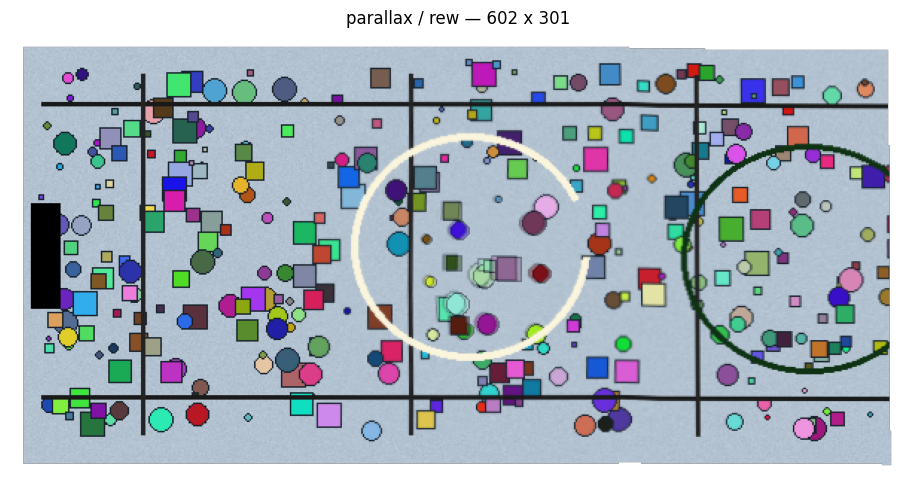

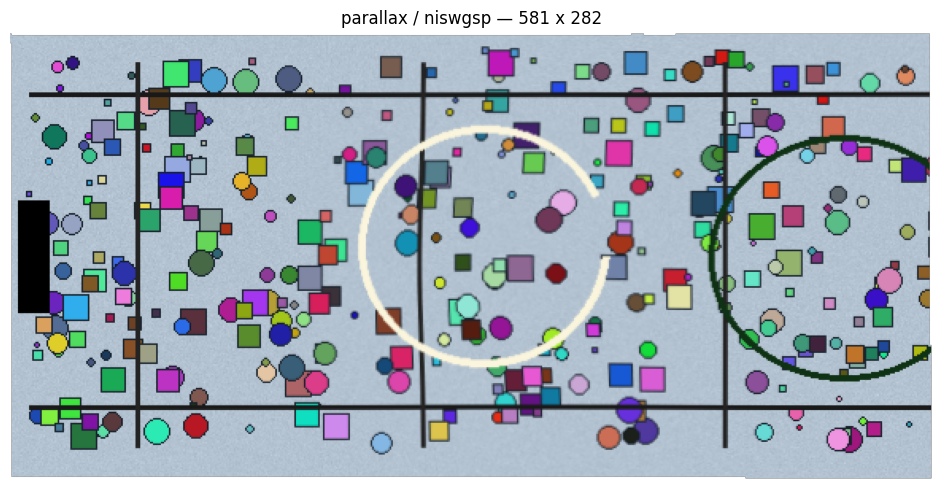

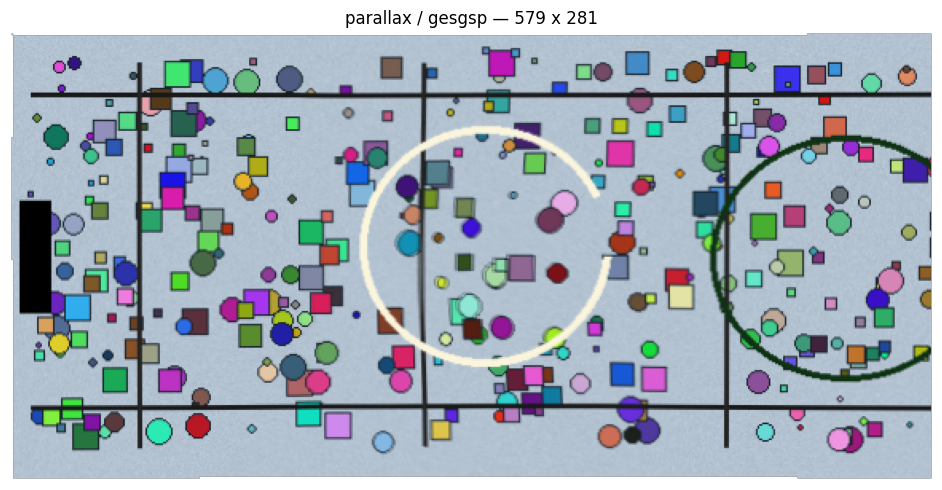

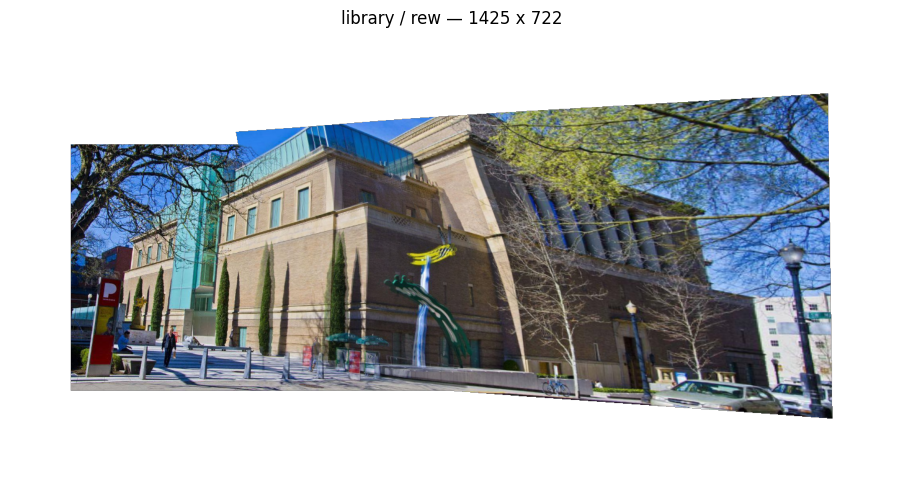

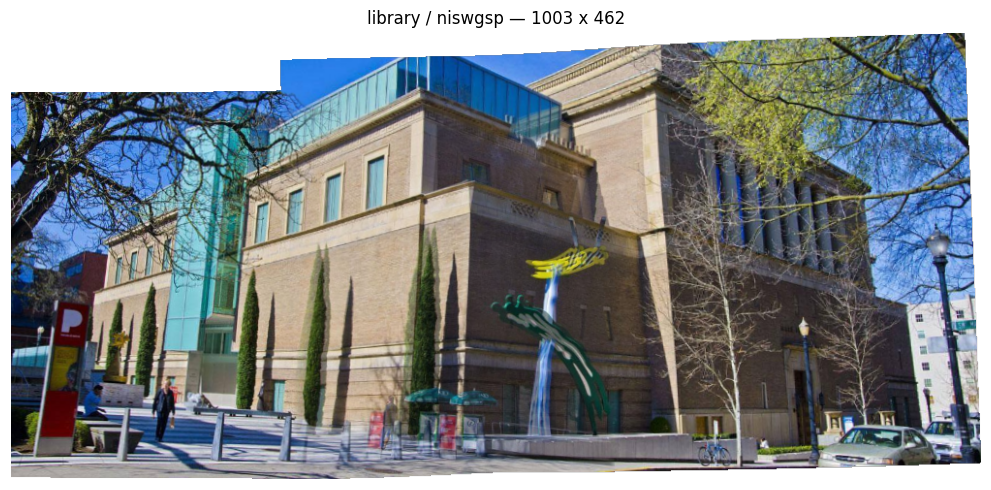

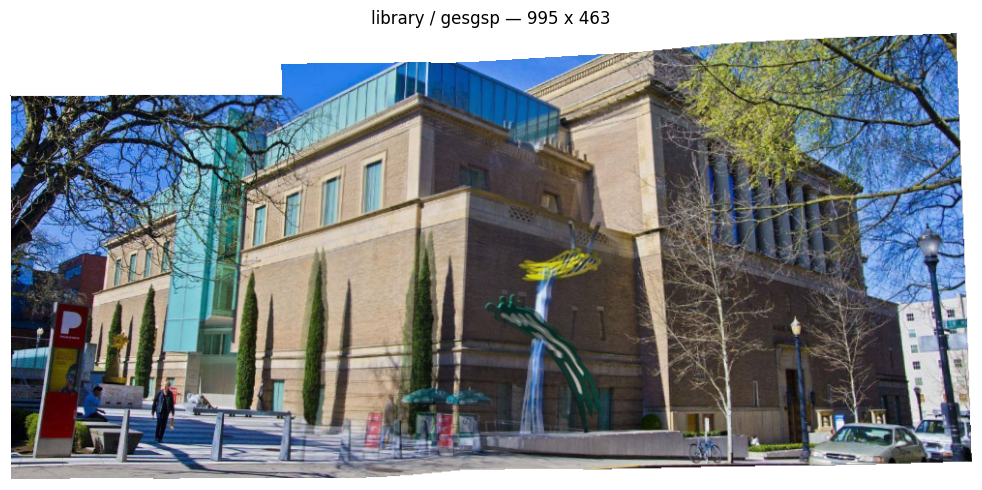

In [9]:
# 全18出力を保存します。Notebookでは視差例と実画像1組を全手法で表示します。
for case, run in runs.items():
    for method, result in run.outputs.items():
        result.save(OUT / f"{case}_{method}.png")
        (OUT / f"{case}_{method}.json").write_text(result.report_json())
for case in ["parallax", "library"]:
    for method in ["rew", "niswgsp", "gesgsp"]:
        r = runs[case].outputs[method]
        rgba = np.dstack([r.image, r.mask])
        fig, ax = plt.subplots(figsize=(12, 5))
        ax.imshow(rgba)
        ax.set_title(f"{case} / {method} — {r.image.shape[1]} x {r.image.shape[0]}")
        ax.axis("off")
        fig.tight_layout()
        plt.show()


## 構造制約を外した対照実験
同じ位置合わせ結果を用い、GES-GSPで構造検出を無効にした結果とNISwGSPを比較します。
構造制約を追加しない条件で共有処理が一致するかを検証するものであり、実画像全般での優位性を示す実験ではありません。


In [10]:
scene = sk.prepare(inputs["library"], OPTIONS)
without_structure = sk.compose(scene, OPTIONS.with_updates(method="gesgsp", structures="none"))
nis = sk.compose(scene, OPTIONS.with_updates(method="niswgsp"))
np.testing.assert_array_equal(without_structure.image, nis.image)
np.testing.assert_array_equal(without_structure.mask, nis.mask)
assert sk.report(without_structure)["structure_equations"] == 0
print("構造制約なしのGES-GSPとNISwGSP: 画素・マスクが完全一致")


構造制約なしのGES-GSPとNISwGSP: 画素・マスクが完全一致


## 別途計測した旧版との比較
以下は `tools/compare_versions.py` と同等の手順で別途採取した記録の読み込みです。上記180試行に追加されるNotebook内の再計測ではありません。
旧版・改訂版ともGCC 14.2のReleaseビルドと同じ依存ライブラリを使い、3枚の合成画像をREWで処理しました。
各1回の予備実行と5回の順序入替えを行っています。位置合わせはC++内部計測、CLI全体はプロセス起動・画像入出力を含む計測です。
コード変更による効果の比較であり、全処理／位置合わせ済み処理の比較とは区別してください。

In [11]:
before_after_path = ROOT / "results/refactor_comparison/before_after_raw.csv"
if before_after_path.is_file():
    before_after = pd.read_csv(before_after_path)
    historical = before_after.groupby("version")[["registration_ms", "cli_wall_including_io_ms"]].median()
    display(historical.round(3))
    protocol = json.loads(before_after_path.with_name("protocol.json").read_text())
    print("比較時のRGBA完全一致:", protocol["output_rgba_identical"])
    print("この表は同梱した別計測の記録です。現在の端末で再計測した値ではありません。")
else:
    print("旧版との別計測記録はありません。tools/compare_versions.py に両版の実行ファイルを指定して採取できます。")

,registration_ms,cli_wall_including_io_ms
version,,
baseline_0.1,293.103,398.250
refactor_0.2,222.758,325.962


比較時のRGBA完全一致: True
この表は同梱した別計測の記録です。現在の端末で再計測した値ではありません。


## 解釈上の制限と残課題
測定値はこのCPU・入力寸法・実装・実行環境に限る結果です。端末間の性能比較、CUDAの速度予測、学習済みLINEAEの性能評価には使えません。
5回の反復に加え、異なる端末・入力サイズ・十分な画像集合での評価が必要です。

現実装には露出補正、継ぎ目探索、多重解像度合成、画像接続グラフの自動推定はありません。
SIFTの一部には全体の排他制御が残り、GILの解放だけで全処理が並列に速くなるわけではありません。
VLFeatの確保失敗時のプロセス終了と、Python環境の完全な依存固定が未検証である点も、`docs/REVIEW.md` に明記しています。

CUDAとLINEAEの実機試験は未実施です。このNotebookはCPUのみを使用しています。
